In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os
import math
from collections import defaultdict

In [2]:
df_distribution = pd.read_csv('data-analysis/data/all_results_distribution.csv')
df_distance = pd.read_csv('data-analysis/data/all_results_vector_space.csv')

In [3]:
df_distribution.head()

,Dataset,Model,Measure,Drift Strength,Mean,Std
0,yelp_review_full,nlpaueb/sec-bert-base,kl,0.00,87.871948,15.736251
1,yelp_review_full,nlpaueb/sec-bert-base,kl,0.25,109.592061,21.584362
2,yelp_review_full,nlpaueb/sec-bert-base,kl,0.50,134.533282,26.071187
3,yelp_review_full,nlpaueb/sec-bert-base,kl,0.75,158.013560,31.670049
4,yelp_review_full,nlpaueb/sec-bert-base,kl,1.00,165.475173,32.835972


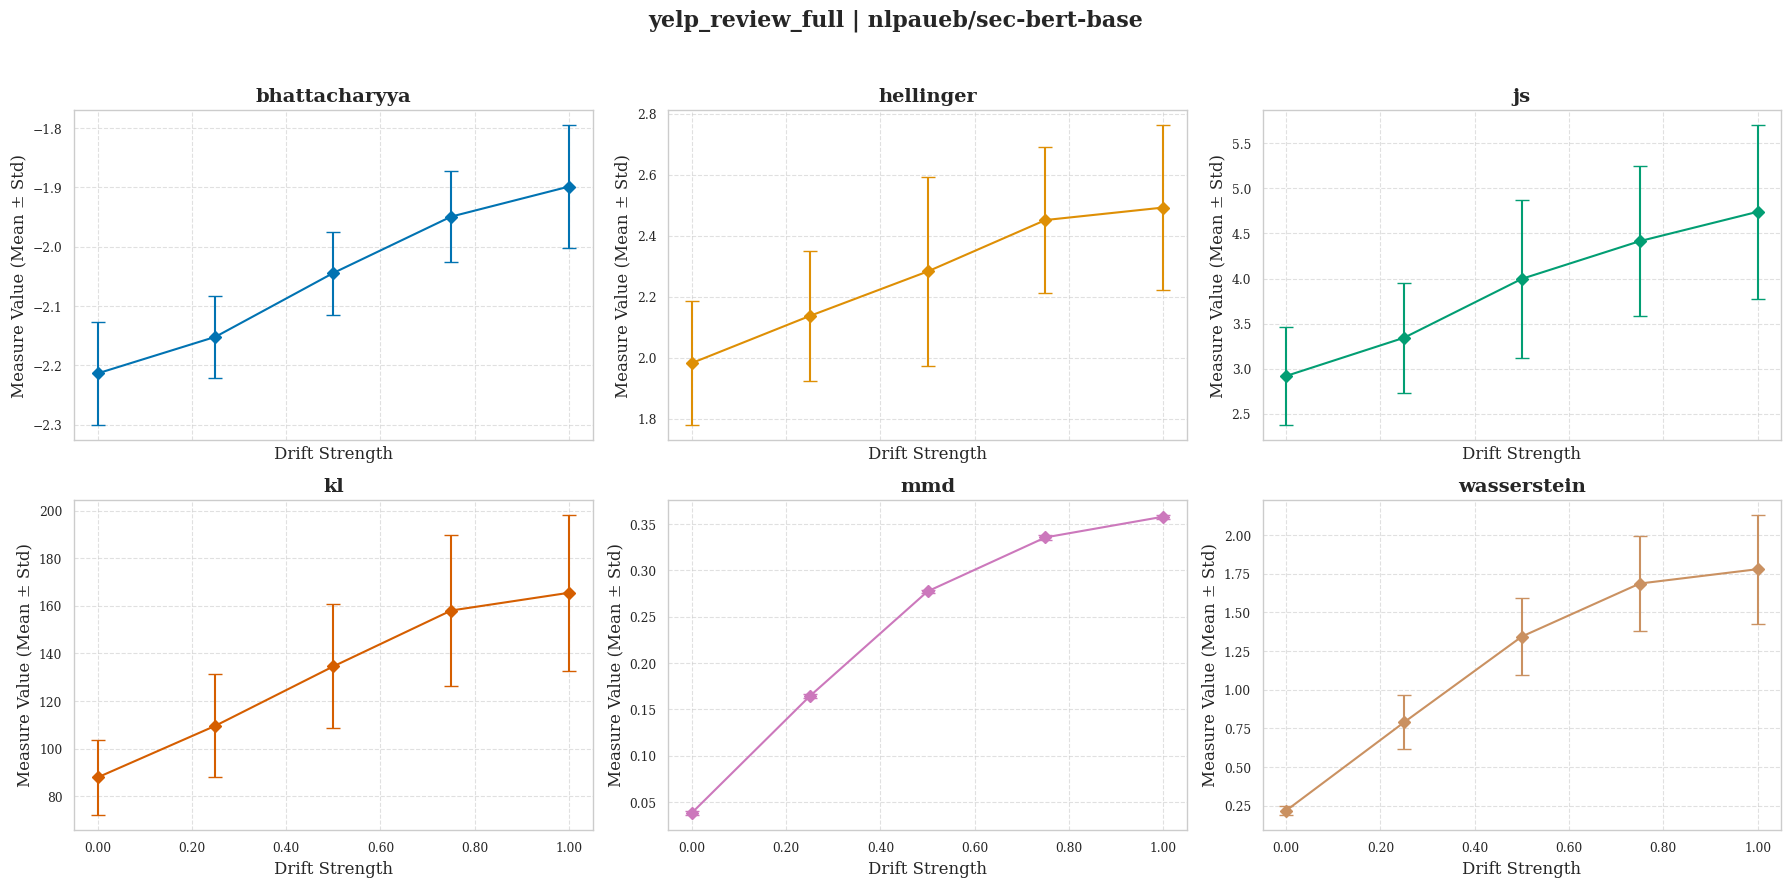

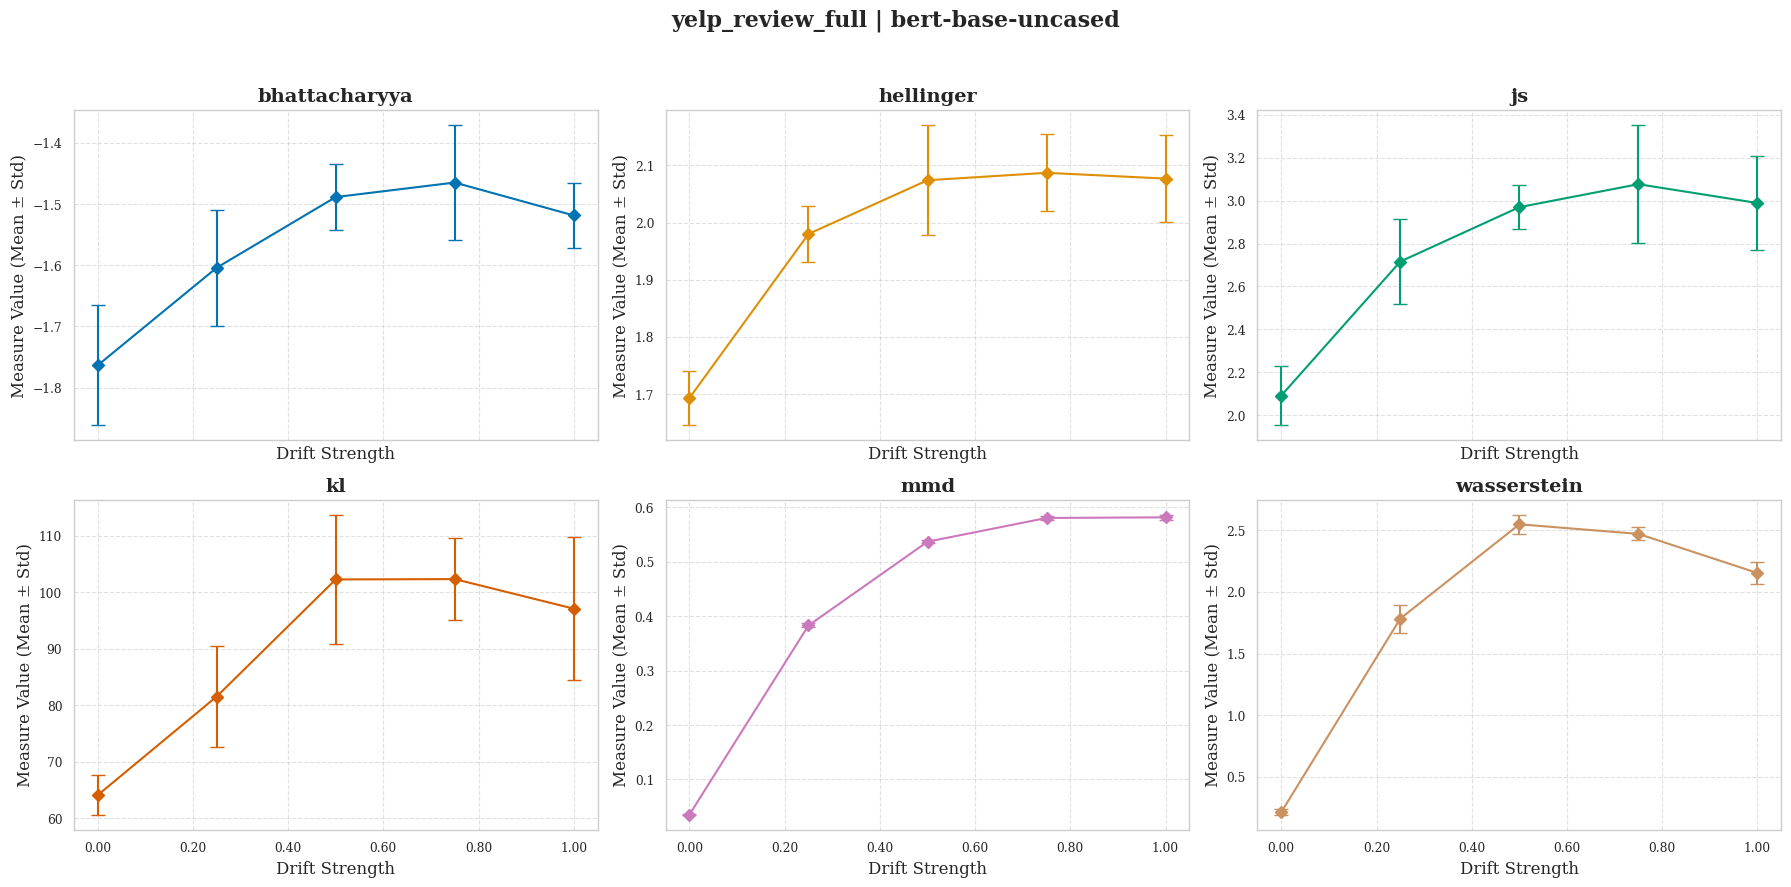

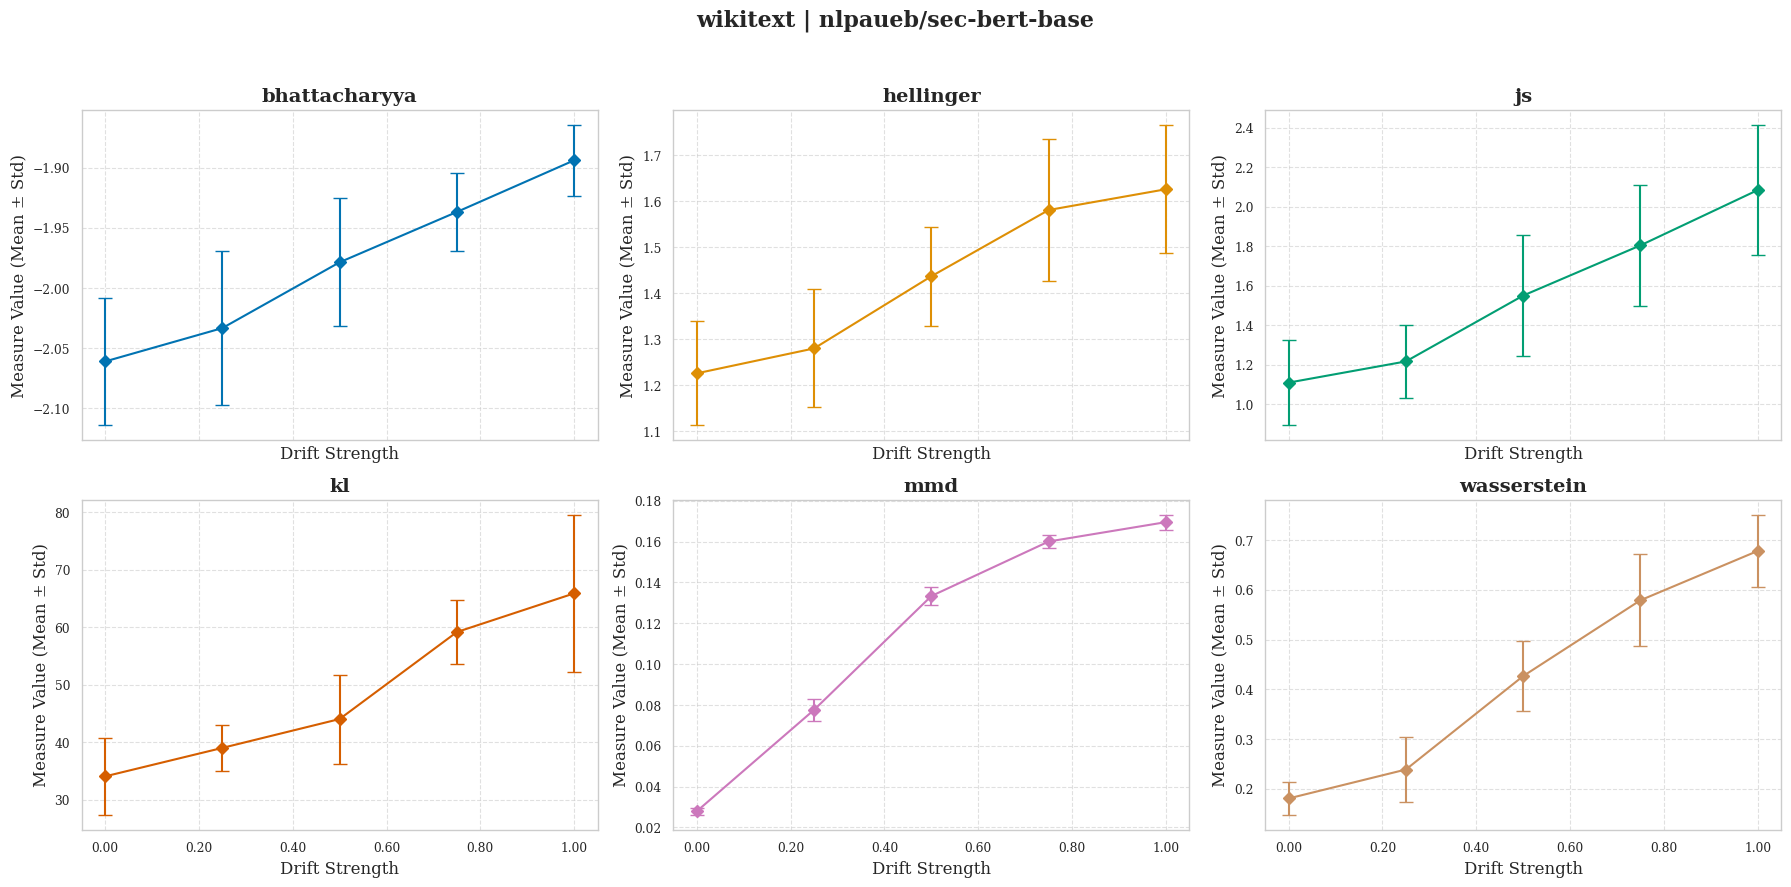

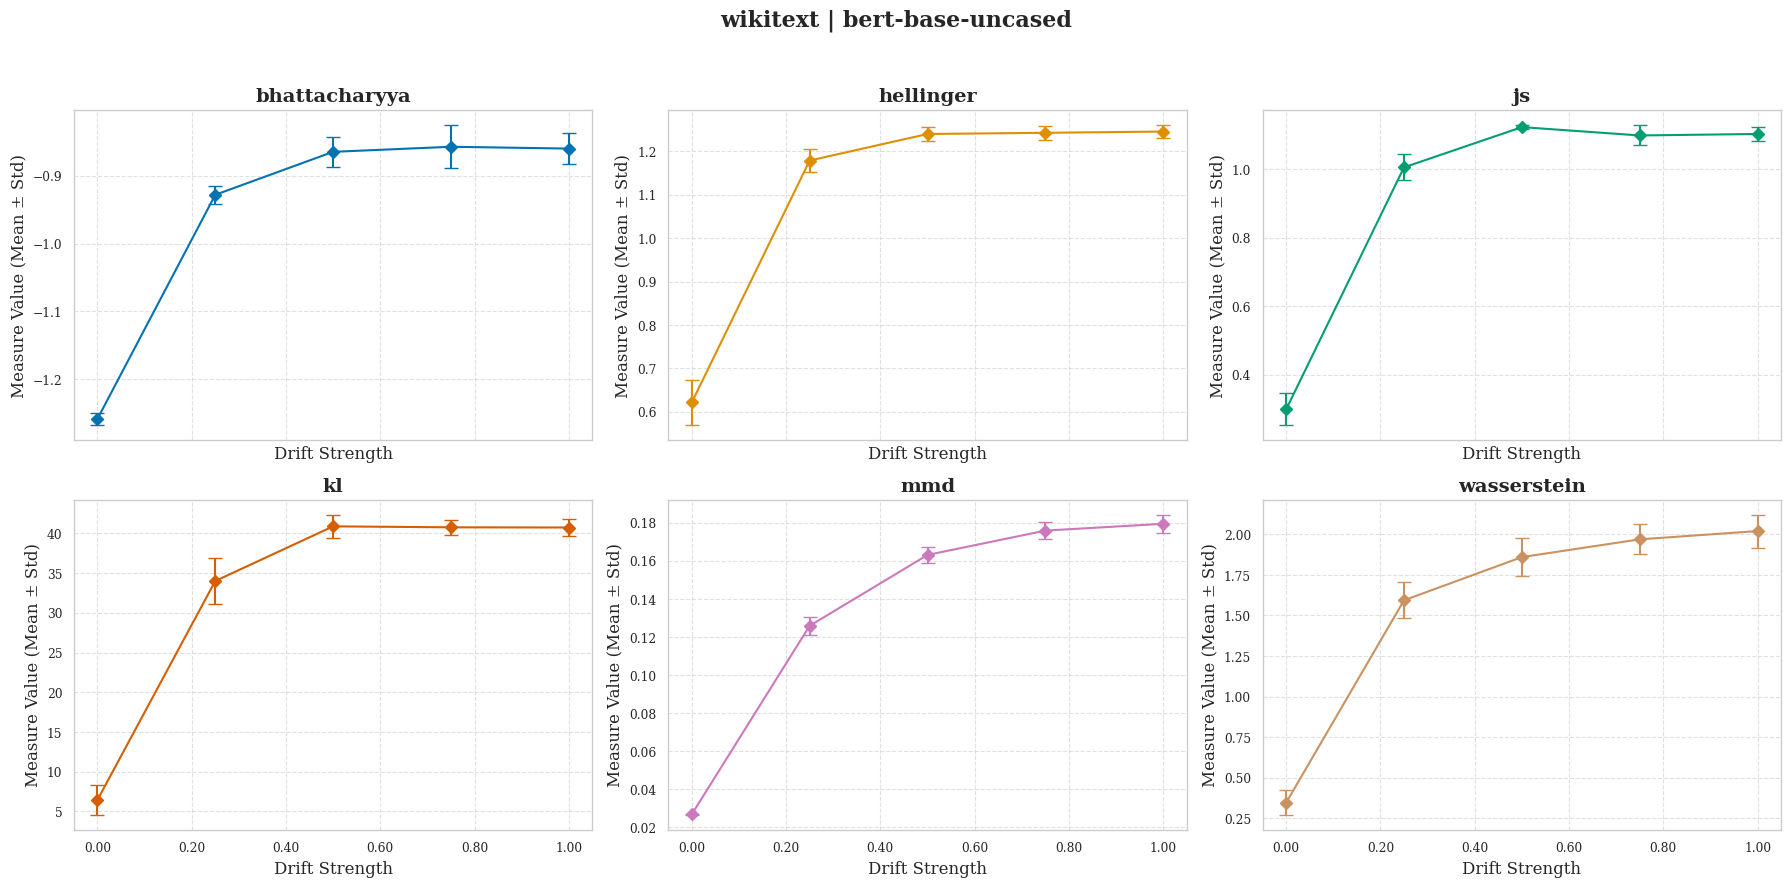

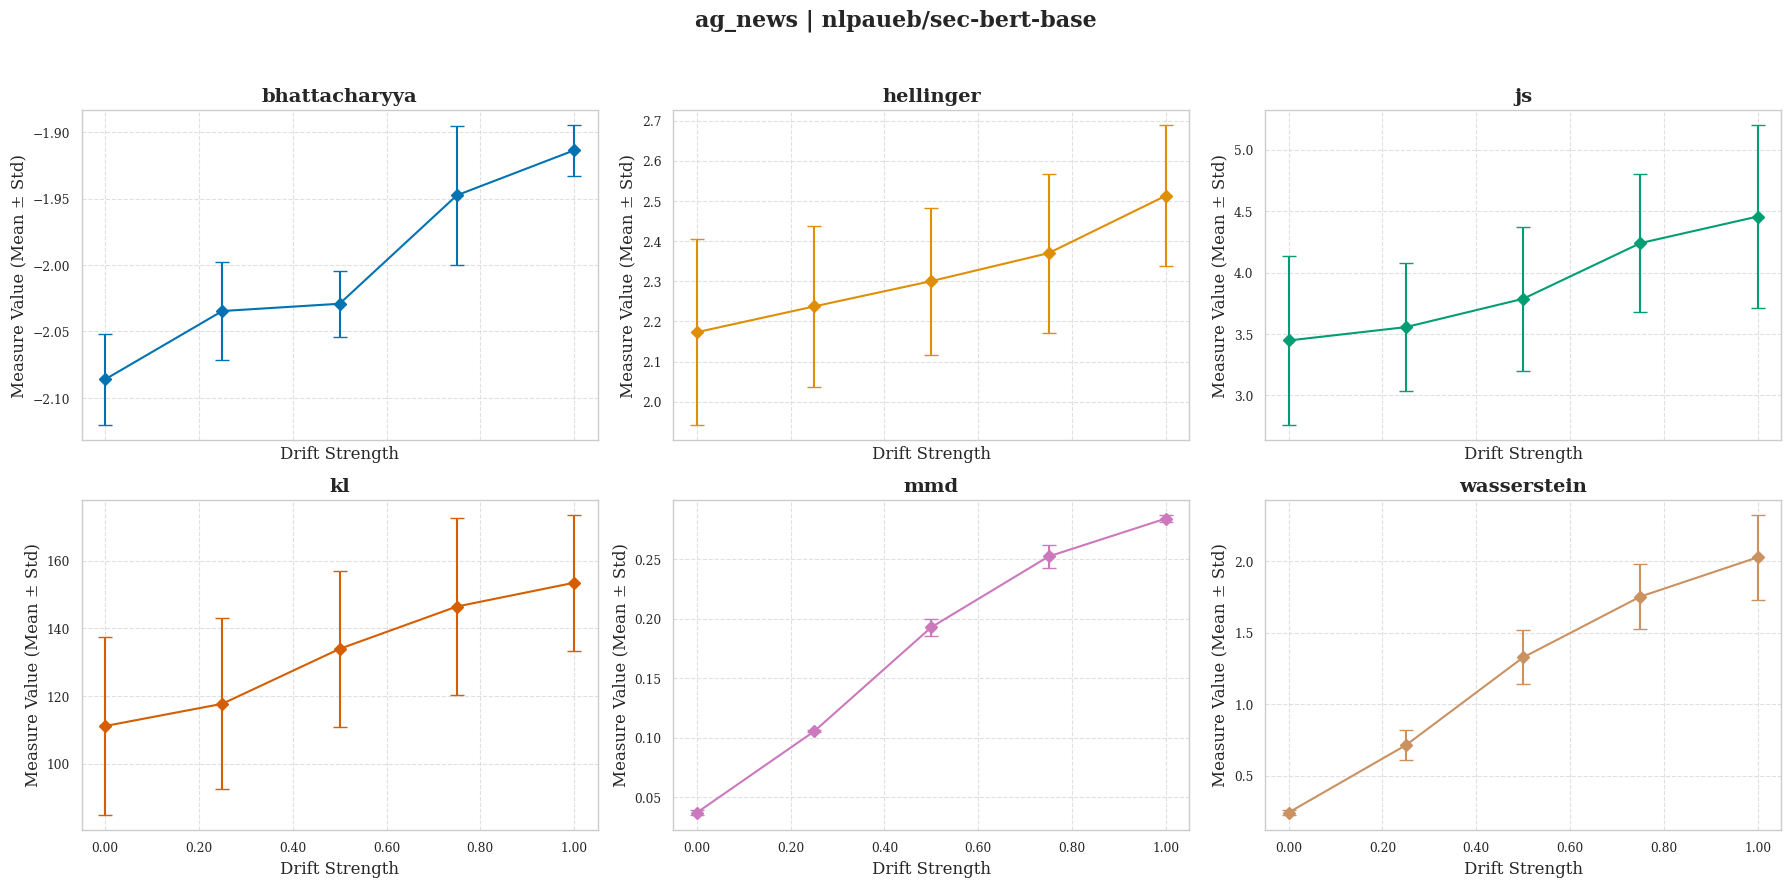

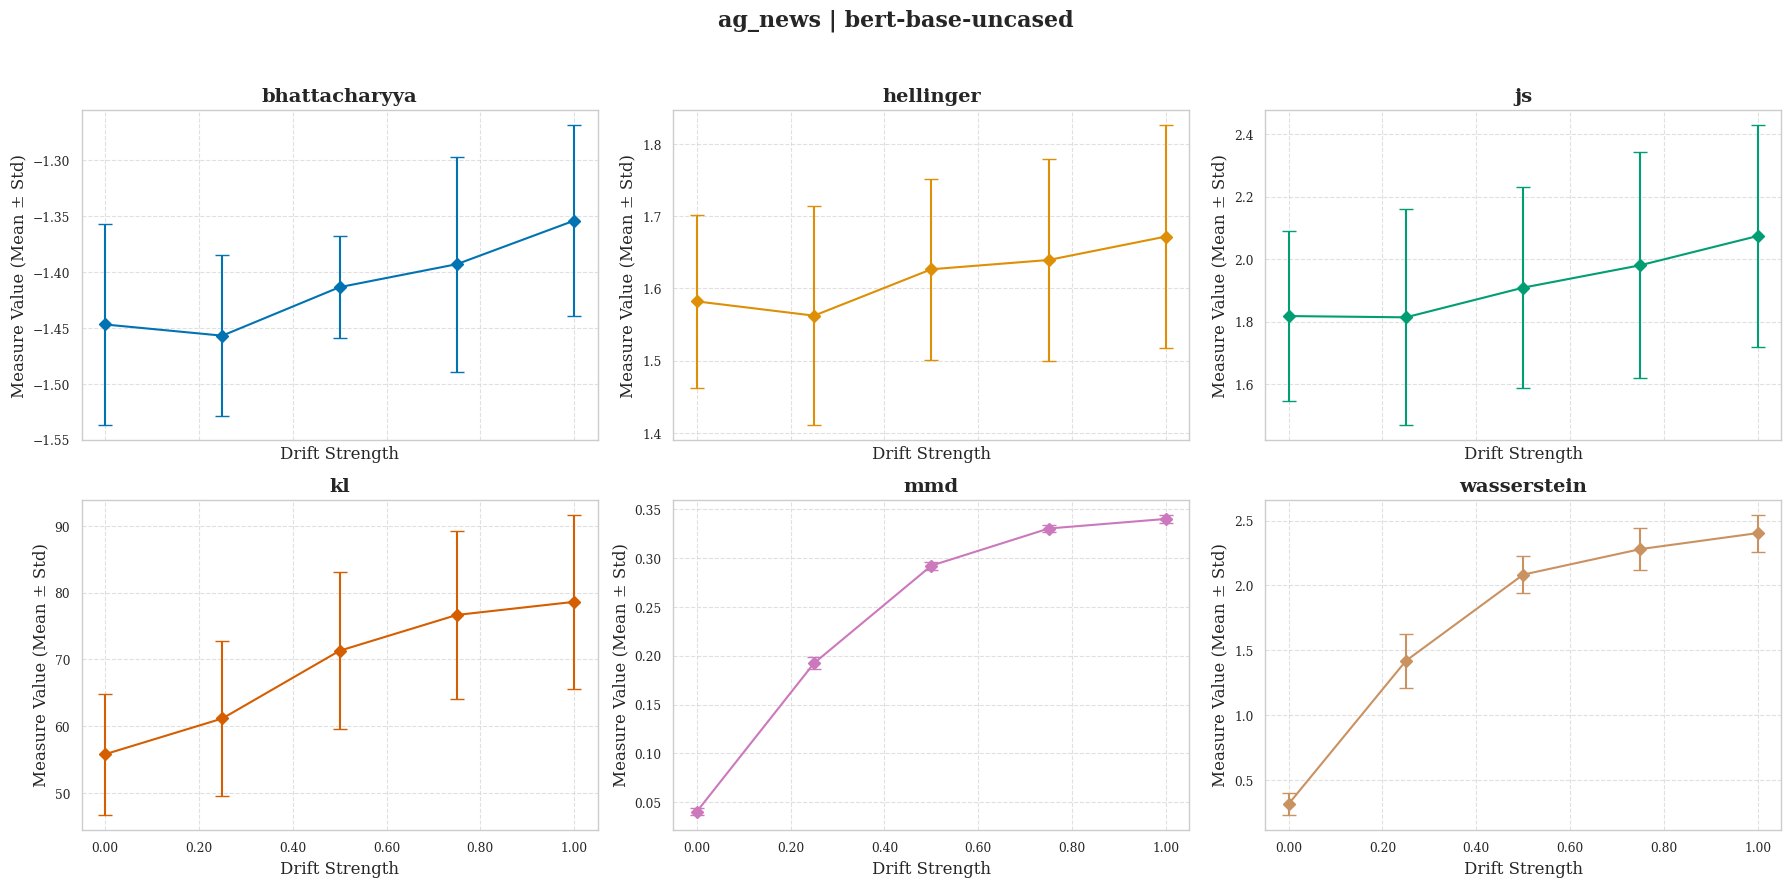

In [4]:
# Set academic-style plot aesthetics
sns.set_context("paper")
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "serif"  # Use serif font for academic style


def plot_measure_with_error_bars(df_distance, output_dir="."):
    """
    Aggregate across (Dataset, Model, Measure, Drift Strength) and plot error bars
    for each drift strength.
    """
    grouped = defaultdict(list)
    for _, row in df_distance.iterrows():
        key = (row["Dataset"], row["Model"], row["Measure"], row["Drift Strength"])
        grouped[key].append((row["Mean"], row["Std"]))
    
    aggregated_data = []
    for key, values in grouped.items():
        dataset_name, model_name, measure, drift_strength = key
        mean_vals = [v[0] for v in values]
        std_vals = [v[1] for v in values]
        aggregated_data.append({
            "dataset_name": dataset_name,
            "model_name": model_name,
            "measure": measure,
            "drift_strength": drift_strength,
            "mean_val": np.mean(mean_vals),
            "std_val": np.mean(std_vals)
        })
    
    grouped_by_model = defaultdict(list)
    for row in aggregated_data:
        grouped_by_model[(row["dataset_name"], row["model_name"])].append(row)
    
    for (dataset_name, model_name), rows in grouped_by_model.items():
        measures = sorted(set(r["measure"] for r in rows))
        n_measures = len(measures)
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16, fontweight='bold')
    
        colors = sns.color_palette("colorblind", n_colors=n_measures)  # Use colorblind-friendly colors
    
        for i, measure in enumerate(measures):
            ax = axs[i]
            measure_rows = [r for r in rows if r["measure"] == measure]
            sorted_rows = sorted(measure_rows, key=lambda x: x["drift_strength"])
    
            x_vals = [r["drift_strength"] for r in sorted_rows]
            y_vals = [r["mean_val"] for r in sorted_rows]
            e_vals = [r["std_val"] for r in sorted_rows]
    
            ax.errorbar(x_vals, y_vals, yerr=e_vals, fmt='D-', capsize=5, markersize=6, 
                        linewidth=1.5, color=colors[i], label=measure)
    
            ax.set_title(measure, fontsize=14, fontweight='bold')
            ax.set_xlabel("Drift Strength", fontsize=12)
            ax.set_ylabel("Measure Value (Mean ± Std)", fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)
            # ax.legend(loc="upper left", bbox_to_anchor=(1,1), fontsize=10)
    
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))  # Format x-axis labels
    
        for j in range(i+1, n_rows * n_cols):
            axs[j].set_visible(False)
    
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        # fname = f"{dataset_name}_{model_name.replace('/', '_')}_measure_errorbars_optimised.png"
        # save_path = os.path.join(output_dir, fname)
        # plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        plt.show()
        # print(f"Saved figure: {save_path}")

# Example usage:
plot_measure_with_error_bars(df_distribution, output_dir="data-analysis/data-test")


In [5]:
df_distance.head()

,distance_name,drift_strength,pca,final_similarity,seed,Dataset,Model
0,mahalanobis,0.00,False,0.822321,0,yelp_review_full,nlpaueb/sec-bert-base
1,mahalanobis,0.00,True,0.152716,0,yelp_review_full,nlpaueb/sec-bert-base
2,mahalanobis,0.25,False,1.473224,0,yelp_review_full,nlpaueb/sec-bert-base
3,mahalanobis,0.25,True,0.618627,0,yelp_review_full,nlpaueb/sec-bert-base
4,mahalanobis,0.50,False,2.016730,0,yelp_review_full,nlpaueb/sec-bert-base


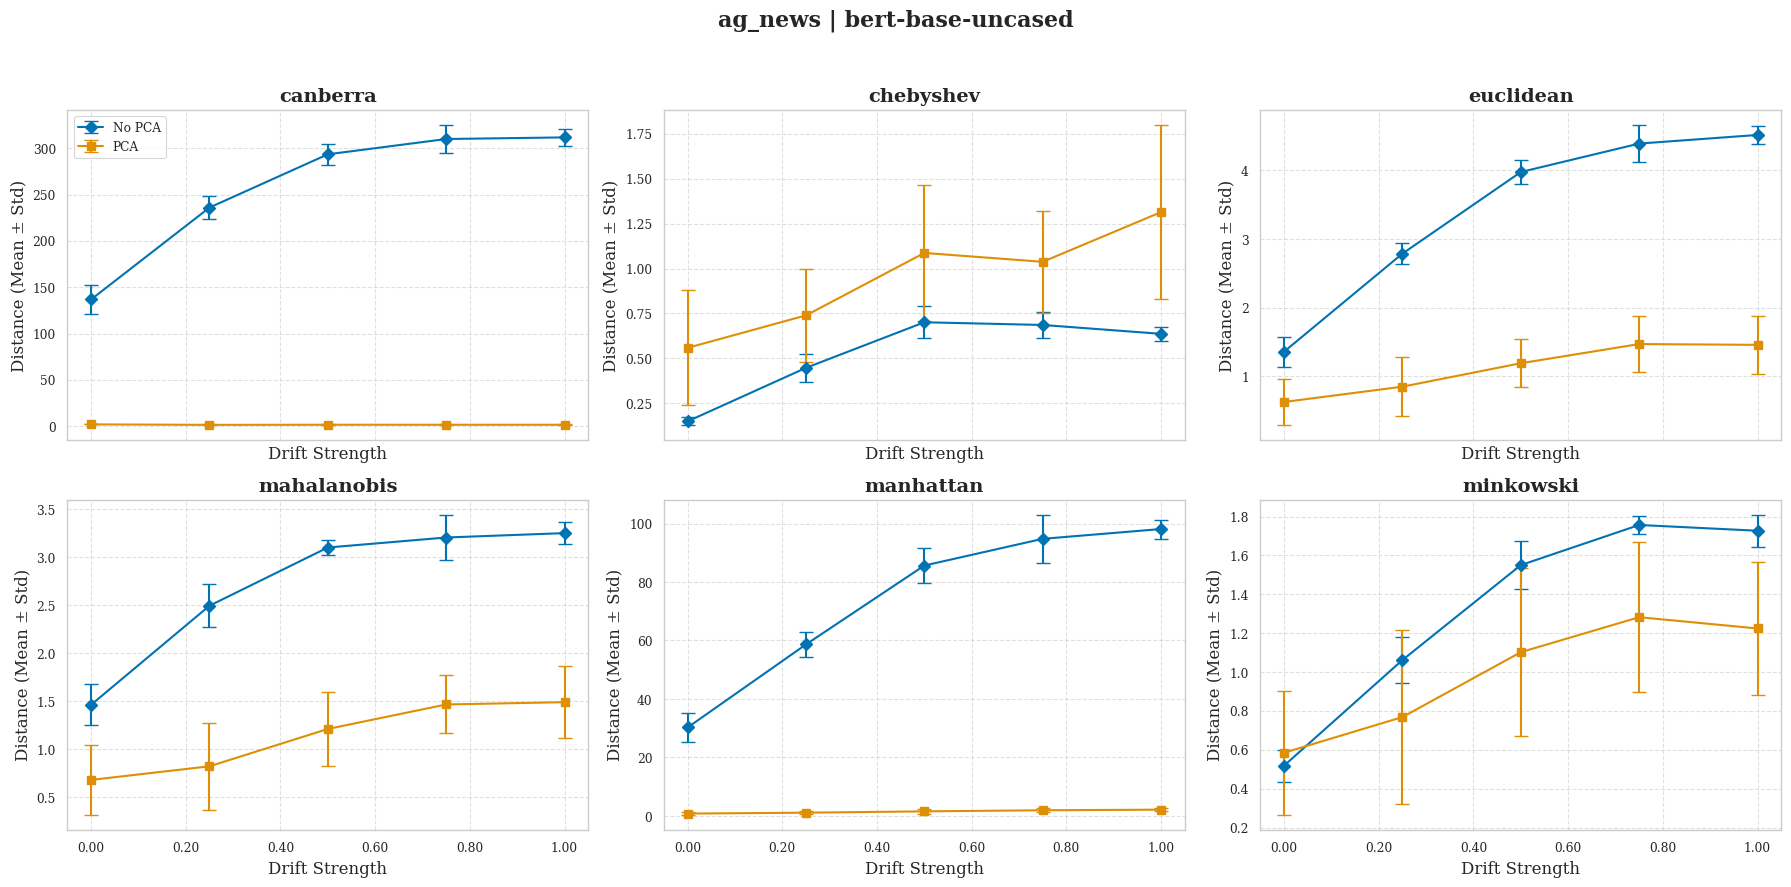

Saved figure: data-analysis/data-test/ag_news_bert-base-uncased_distances_errorbars.png


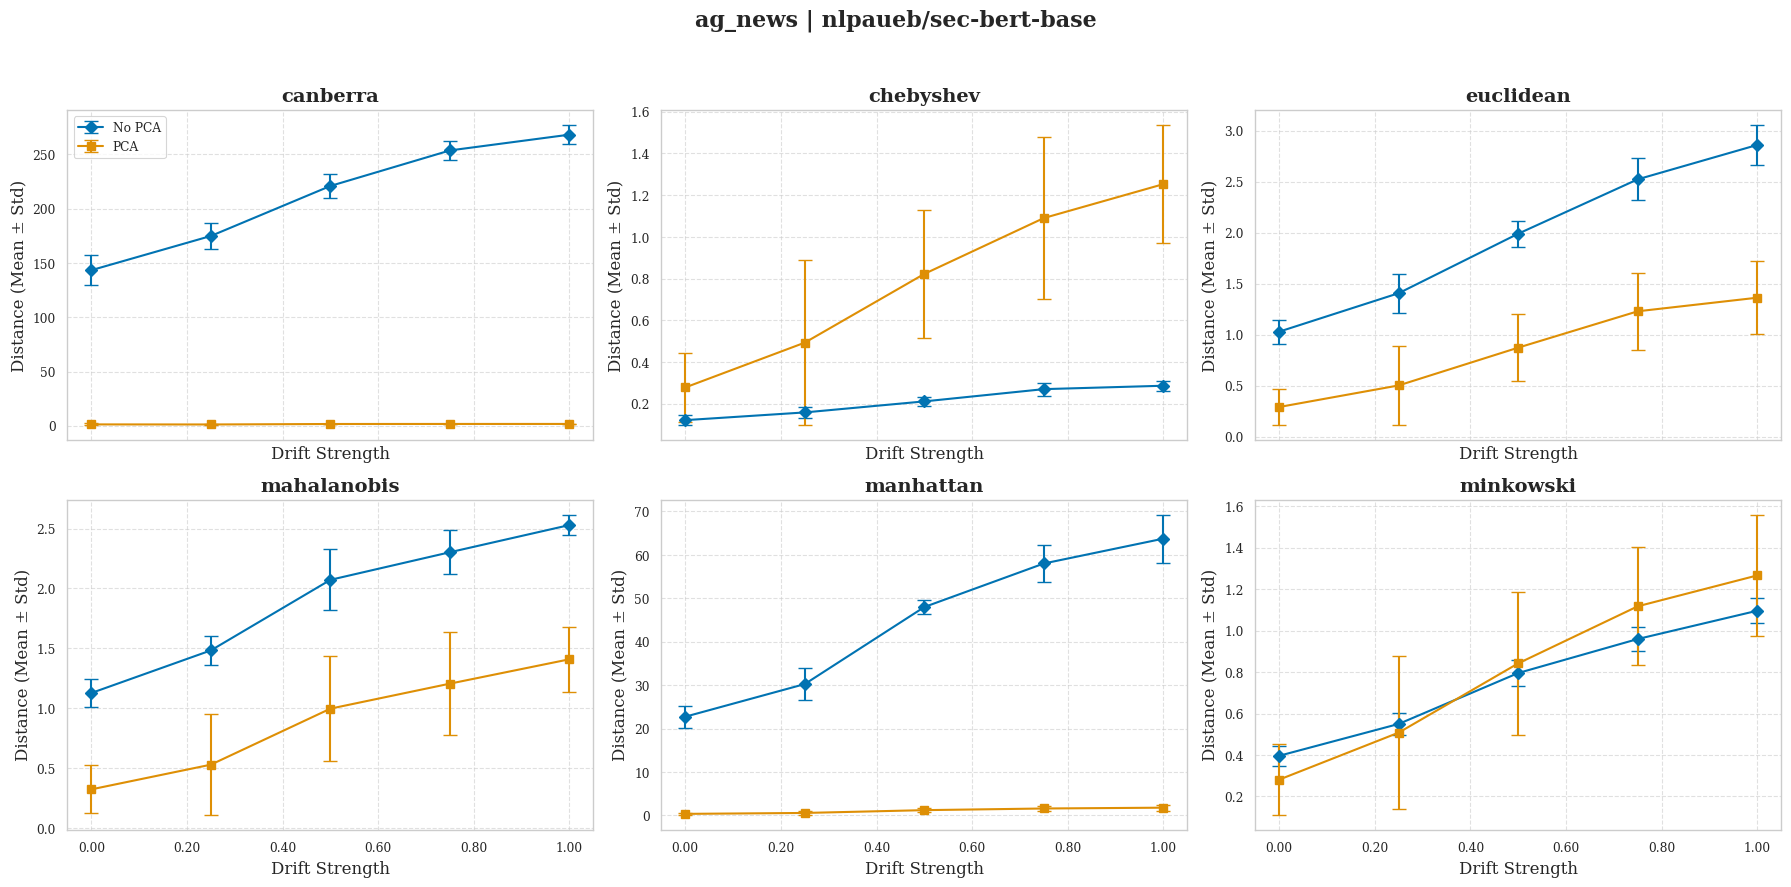

Saved figure: data-analysis/data-test/ag_news_nlpaueb_sec-bert-base_distances_errorbars.png


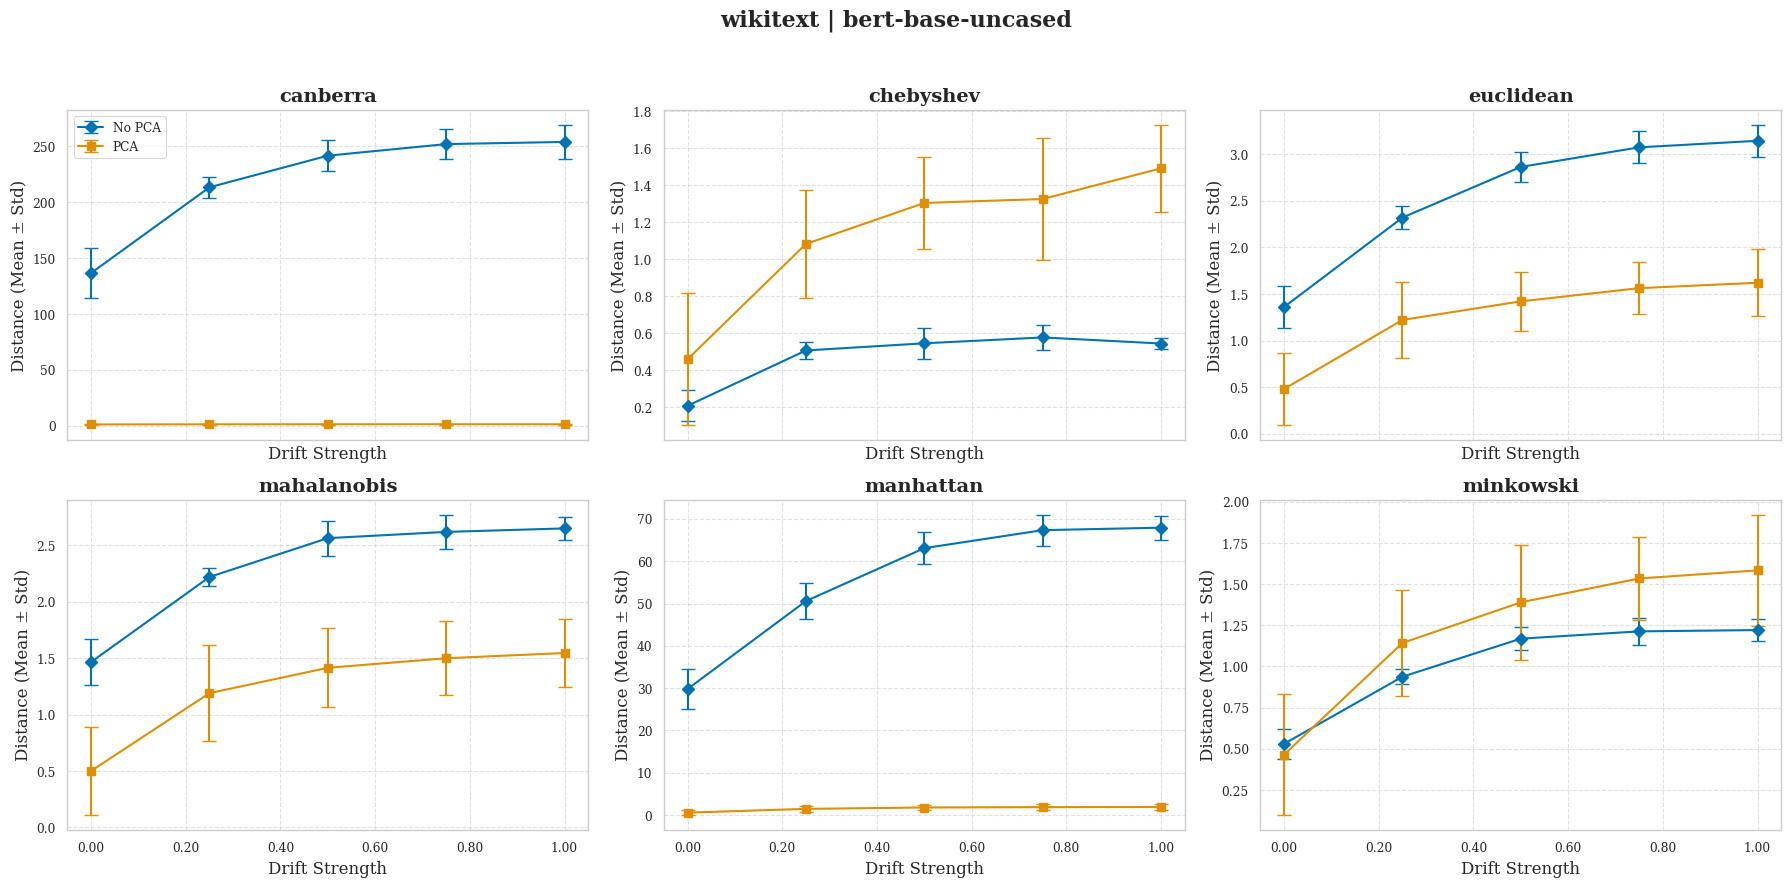

Saved figure: data-analysis/data-test/wikitext_bert-base-uncased_distances_errorbars.png


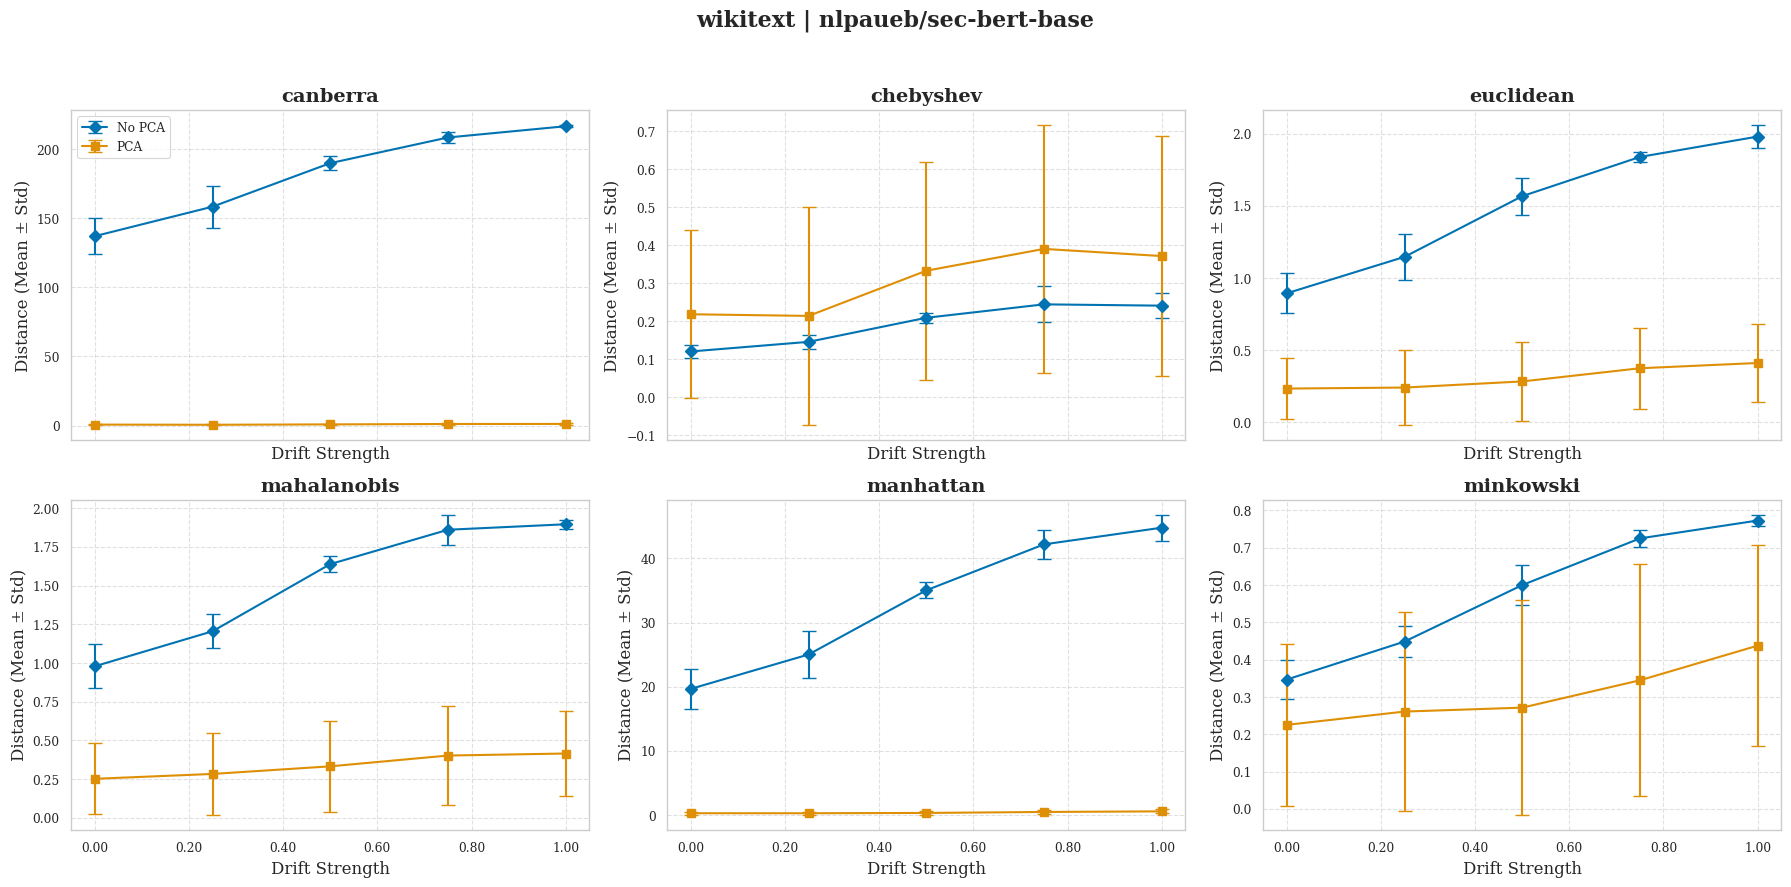

Saved figure: data-analysis/data-test/wikitext_nlpaueb_sec-bert-base_distances_errorbars.png


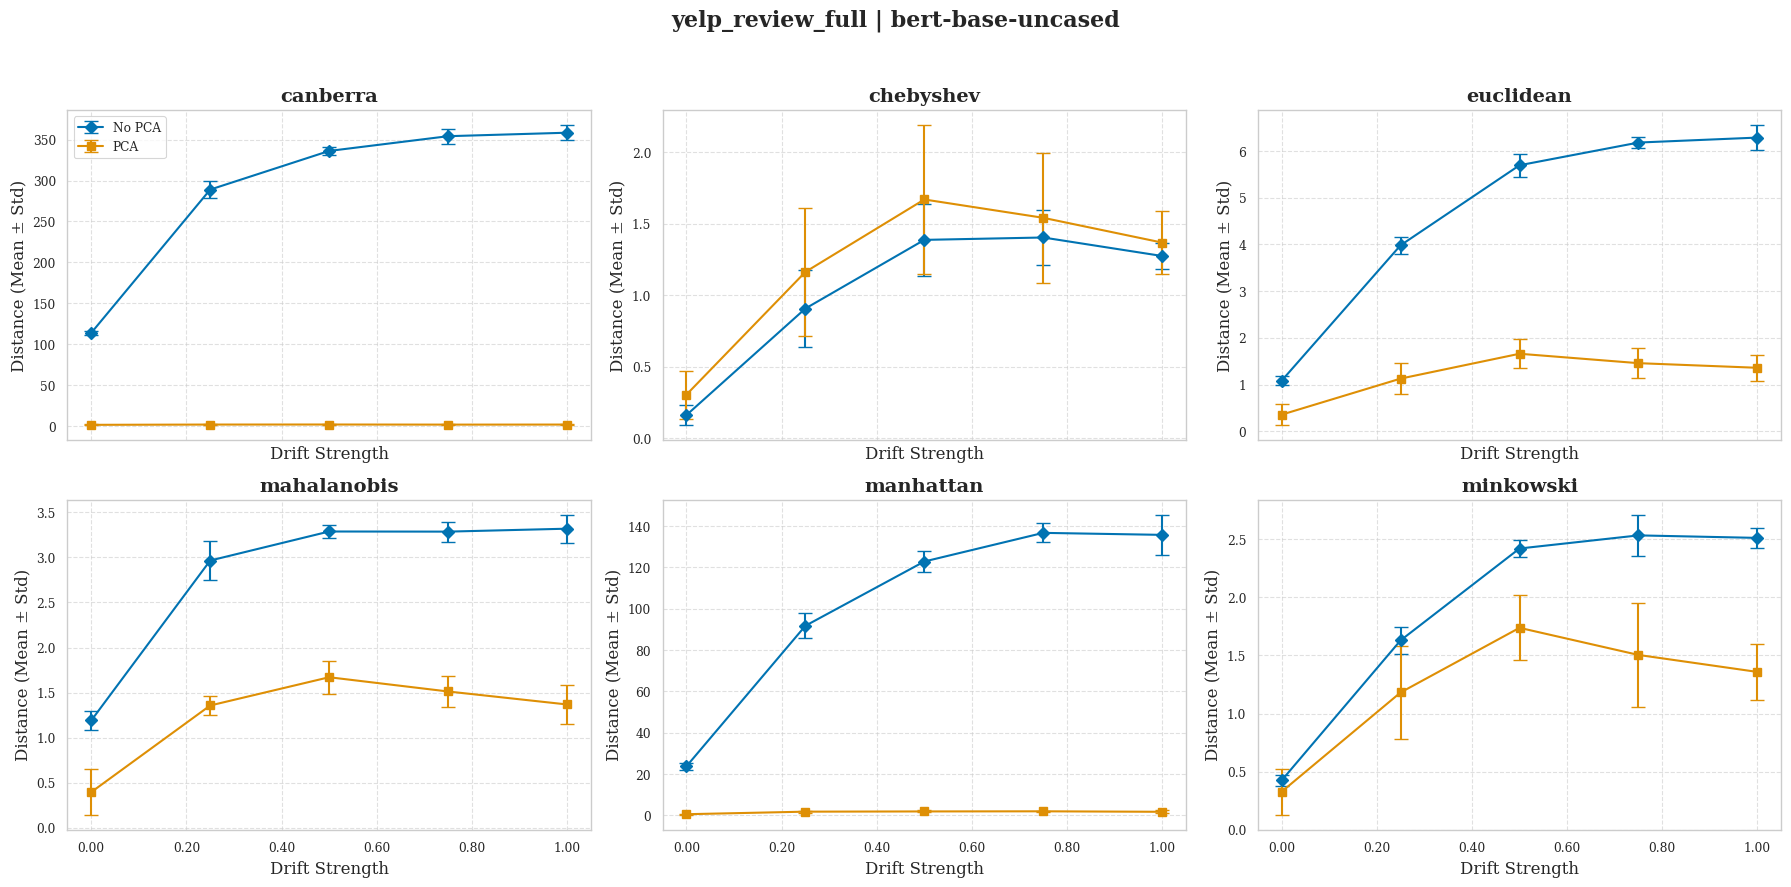

Saved figure: data-analysis/data-test/yelp_review_full_bert-base-uncased_distances_errorbars.png


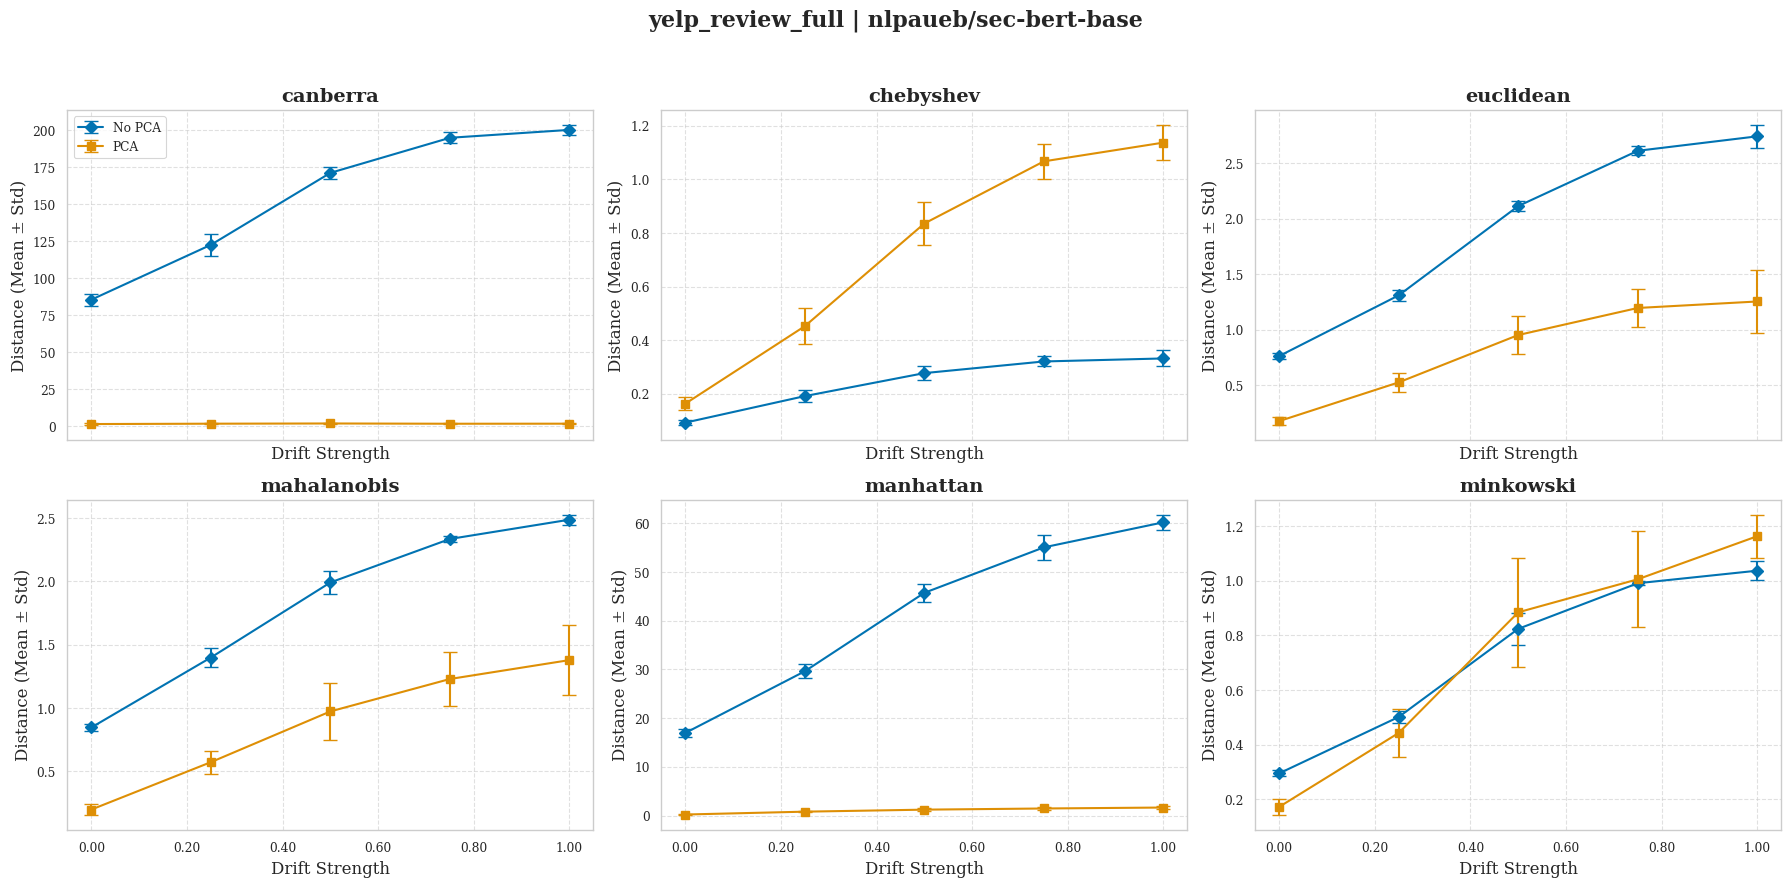

Saved figure: data-analysis/data-test/yelp_review_full_nlpaueb_sec-bert-base_distances_errorbars.png


In [9]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set academic-style plot aesthetics
sns.set_context("paper")
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "serif"  # Use serif font for academic style

def plot_distance_with_error_bars(df, output_dir="."):
    """
    For each combination of (Dataset, Model, distance_name, pca, drift_strength),
    aggregate the final_similarity values (across seeds) by computing the mean and std.
    Then, for each (Dataset, Model), produce a plot with error bars (mean ± std) for each
    distance_name, comparing "No PCA" and "PCA" lines.
    
    Parameters:
      df         : pandas DataFrame with columns:
                   "distance_name", "drift_strength", "pca", "final_similarity", 
                   "seed", "Dataset", "Model"
      output_dir : Directory where plots will be saved.
    """
    # Aggregate across seeds: group by Dataset, Model, distance_name, pca, drift_strength.
    aggregated = df.groupby(["Dataset", "Model", "distance_name", "pca", "drift_strength"])["final_similarity"] \
                   .agg(["mean", "std"]).reset_index()
    
    # Rename columns for consistency with plotting code.
    aggregated.rename(columns={
        "Dataset": "dataset_name",
        "Model": "model_name",
        "mean": "mean_val",
        "std": "std_val",
        "drift_strength": "drift_strength"
    }, inplace=True)
    
    # Group by (dataset_name, model_name) to generate a separate plot per combination.
    grouped_by_model = defaultdict(list)
    for _, row in aggregated.iterrows():
        key = (row["dataset_name"], row["model_name"])
        grouped_by_model[key].append(row)
    
    # For each dataset/model combination, create a plot.
    for (dataset_name, model_name), rows in grouped_by_model.items():
        # Get sorted list of unique distance names.
        dist_names = sorted({row["distance_name"] for row in rows})
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True)
        
        # Flatten axs for easy iteration.
        if n_dists == 1:
            axs = [axs]
        else:
            axs = axs.flatten()
        
        # Use a colorblind-friendly palette for the two lines (No PCA and PCA).
        colors = sns.color_palette("colorblind", n_colors=2)
        
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16, fontweight='bold')
        
        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            # Filter data for the current distance.
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            
            # Separate rows by PCA flag.
            no_pca = sorted([r for r in dist_rows if r["pca"] == False],
                            key=lambda x: x["drift_strength"])
            pca = sorted([r for r in dist_rows if r["pca"] == True],
                         key=lambda x: x["drift_strength"])
            
            # Extract x-values (drift_strength), y-values (mean_val), and errors (std_val).
            x_no_pca = [r["drift_strength"] for r in no_pca]
            y_no_pca = [r["mean_val"] for r in no_pca]
            e_no_pca = [r["std_val"] for r in no_pca]
            
            x_pca = [r["drift_strength"] for r in pca]
            y_pca = [r["mean_val"] for r in pca]
            e_pca = [r["std_val"] for r in pca]
            
            # Plot error bars for "No PCA" using a diamond marker.
            ax.errorbar(x_no_pca, y_no_pca, yerr=e_no_pca,
                        fmt='D-', capsize=5, markersize=6, linewidth=1.5,
                        color=colors[0], label="No PCA")
            
            # Plot error bars for "PCA" using a square marker.
            ax.errorbar(x_pca, y_pca, yerr=e_pca,
                        fmt='s-', capsize=5, markersize=6, linewidth=1.5,
                        color=colors[1], label="PCA")
            
            ax.set_title(dist_name, fontsize=14, fontweight='bold')
            ax.set_xlabel("Drift Strength", fontsize=12)
            ax.set_ylabel("Distance (Mean ± Std)", fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
            
            # Show legend only on the first subplot.
            if i == 0:
                ax.legend()
        
        # Hide any unused subplots.
        for j in range(i+1, n_rows * n_cols):
            axs[j].set_visible(False)
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        plt.show()
        print(f"Saved figure: {save_path}")

# Example usage:
# Assuming your dataframe is named df_distribution and you want to save plots in a given output directory:
plot_distance_with_error_bars(df_distance, output_dir="data-analysis/data-test")
